# License Plate Detection in Fog Conditions
**Pipeline:** Synthetic Fog Generation → Defogging → YOLOv11n Detection

> Run **Section A** once to generate & upload the foggy dataset to Kaggle.  
> Run **Section B** for model training & inference using the foggy dataset.

In [1]:
import cv2 
import numpy as np
import os
import yaml
import shutil
import time
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
%matplotlib inline

---
## Section A — Synthetic Heavy Fog Generation
Adds heavy synthetic fog to every image in the original dataset and saves to a new folder structure ready for Kaggle upload.  
Labels are copied unchanged (bounding boxes are unaffected by fog).

In [3]:
# ── Fog parameters (heavy) ──────────────────────────────────────────────────
FOG_INTENSITY = 0.35   # atmospheric-light blend weight  (0=clear, 1=white)
TRANSMISSION  = 0.70   # scene transmission coefficient  (lower = denser fog)

def add_heavy_fog(img: np.ndarray,
                  intensity: float = FOG_INTENSITY,
                  transmission: float = TRANSMISSION) -> np.ndarray:
    
    """
    Simulate heavy fog using the atmospheric scattering model:
        I(x) = J(x) * t(x) + A * (1 - t(x))
    where A = 255 (white atmospheric light), t(x) = transmission map.
    """
    
    img_f = img.astype(np.float32)
    h, w  = img.shape[:2]

    # Depth-dependent transmission map (centre = slightly deeper)
    y_idx = np.linspace(0, 1, h).reshape(-1, 1)
    x_idx = np.linspace(0, 1, w).reshape(1, -1)
    depth = 1.0 - (0.5 * np.exp(-((x_idx - 0.5)**2 + (y_idx - 0.5)**2) / 0.3))
    t_map = (transmission ** depth)[..., np.newaxis]          # (H, W, 1)

    A = 255.0
    foggy  = img_f * t_map + A * (1.0 - t_map)          # I(x) = J(x) * t(x) + A * (1 - t(x))

    # Blend additional atmospheric white-out for heavy fog
    white = np.full_like(img_f, A)
    foggy = foggy * (1.0 - intensity) + white * intensity

    return np.clip(foggy, 0, 255).astype(np.uint8)

In [16]:
# ── Paths ────────────────────────────────────────────────────────────────────
ORIG_DATASET  = './data/licence-plate-dataset'  # dot means we are using cwd 
FOGGY_DATASET = './data/foggy-license-plate-dataset'
SPLITS        = ['train', 'valid', 'test']

for split in SPLITS:
    for sub in ['images', 'labels']:
        Path(f'{FOGGY_DATASET}/{split}/{sub}').mkdir(parents=True, exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png'}

for split in SPLITS:
    src_img = f'{ORIG_DATASET}/{split}/images'
    src_lbl = f'{ORIG_DATASET}/{split}/labels'
    dst_img = f'{FOGGY_DATASET}/{split}/images'
    dst_lbl = f'{FOGGY_DATASET}/{split}/labels'

    if not os.path.exists(src_img):
        print(f'[SKIP] {split}/images not found'); continue

    files = [f for f in os.listdir(src_img) if Path(f).suffix.lower() in IMG_EXTS]
    print(f'Processing {split}: {len(files)} images …', end=' ')

    for fname in files:
        img = cv2.imread(f'{src_img}/{fname}')
        if img is None: continue
        foggy = add_heavy_fog(img)
        cv2.imwrite(f'{dst_img}/{fname}', foggy)

        # Copy label file unchanged
        lbl = Path(fname).stem + '.txt'
        src_l = f'{src_lbl}/{lbl}'
        if os.path.exists(src_l):
            shutil.copy2(src_l, f'{dst_lbl}/{lbl}')

    print('done.')

print(f'\nFoggy dataset saved to: {FOGGY_DATASET}')

Processing train: 7057 images … done.
Processing valid: 2048 images … done.
Processing test: 1020 images … done.

Foggy dataset saved to: ./data/foggy-license-plate-dataset


---
## Section B — Defog → Detect
Uses the foggy dataset.  
Images are defogged at inference/training time using Dark Channel Prior.

In [4]:
# ── Dark Channel Prior defogging ─────────────────────────────────────────────
def dark_channel(img: np.ndarray, patch: int = 15) -> np.ndarray:
    """Minimum across colour channels within a local patch."""
    min_ch  = np.min(img, axis=2)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
    return cv2.erode(min_ch, kernel)

def estimate_atmospheric_light(img: np.ndarray, dc: np.ndarray) -> np.ndarray:
    """Top-0.1% brightest pixels in the dark channel → median RGB."""
    flat    = dc.flatten()
    n_pick  = max(1, int(flat.size * 0.001))
    indices = np.argsort(flat)[-n_pick:]
    h, w    = dc.shape
    pixels  = img.reshape(-1, 3)[indices]
    return np.median(pixels, axis=0)

def defog(img: np.ndarray, omega: float = 0.95, patch: int = 15) -> np.ndarray:
    """
    Dark Channel Prior (He et al., 2009).
    omega: haze-removal aggressiveness (0–1)
    """
    img_f = img.astype(np.float64) / 255.0
    dc    = dark_channel(img_f, patch)
    A     = estimate_atmospheric_light(img_f, dc)          # (3,)

    # Normalised dark channel
    norm  = img_f / (A + 1e-6)
    dc_n  = dark_channel(norm, patch)

    # Transmission map (guided filter refinement skipped for speed)
    t     = 1.0 - omega * dc_n
    t     = np.clip(t, 0.1, 1.0)[..., np.newaxis]

    # Recover scene radiance
    J     = (img_f - A) / t + A
    J     = np.clip(J, 0, 1)
    return (J * 255).astype(np.uint8)

In [5]:
# ── YAML config for the foggy dataset ────────────────────────────────────────
FOGGY_KAGGLE = './data/foggy-license-plate-dataset'  

yaml_path = './data/data.yaml'

yaml_content = {
    'path'  : os.path.abspath('./data/foggy-license-plate-dataset'),
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : 1,
    'names' : ['License_Plate']
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print('YAML saved:', yaml_path)

YAML saved: ./data/data.yaml


In [19]:
# ── Train YOLOv11n on foggy images ───────────────────────────────────────────
print('Loading YOLOv11n …')
model = YOLO('yolo11n.pt')

start = time.time()
results = model.train(
    data      = yaml_path,
    epochs    = 25,        # enough for convergence without overfitting
    imgsz     = 416,       # smaller than 640 → much faster, still accurate
    batch     = 8,         # safe for Mac RAM
    device    = 'mps',     # Apple Silicon GPU (use 'cpu' if error)
    patience  = 5,         # stops early if no improvement
    augment   = True,
    workers   = 2,         
    name      = 'lp_fog_detector',
    cache = True,
    project   = './runs'   # saves locally
)
print(f'Training done in {(time.time()-start)/60:.1f} min.')

Loading YOLOv11n …
New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lp_fog_detector2, nbs=64, nms=F

In [6]:
# ── Load best weights ─────────────────────────────────────────────────────────
BEST_MODEL = './runs/detect/runs/lp_fog_detector/weights/best.pt'

if os.path.exists(BEST_MODEL):
    best_model = YOLO(BEST_MODEL)
    print('Best model loaded.')
else:
    print(f'best.pt not found at {BEST_MODEL}')
    print('Falling back to last.pt ...')
    LAST_MODEL = '/runs/detect/runs/lp_fog_detector/weights/last.pt'
    best_model = YOLO(LAST_MODEL)
    print('Last model loaded.')

Best model loaded.


In [7]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
metrics = best_model.val(data=yaml_path, device='mps')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')

Ultralytics 8.4.26 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M2)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 187.6±81.3 MB/s, size: 55.4 KB)
val: Scanning /Users/prateek/Study/SEM 6 /CV PROJECT /jupyter-notebook/data/foggy-license-plate-dataset/valid/labels.cache... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 343.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 3.6it/s 35.1s0.4s
                   all       2048       2195      0.987      0.928      0.964      0.691
Speed: 0.1ms preprocess, 2.6ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /Users/prateek/Study/SEM 6 /CV PROJECT /jupyter-notebook/runs/detect/val3
mAP50     : 0.9637
mAP50-95  : 0.6906


In [8]:
pip install transformers torchvision


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/prateek/.local/pipx/venvs/notebook/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import torch

# Force CPU - MPS has a bug with torch 2.11 + Python 3.14
torch.backends.mps.is_available = lambda: False

# Load model on CPU forcefully to bypass the bug...
model = YOLO('./runs/detect/runs/lp_fog_detector/weights/best.pt')
model = model.to('cpu')


In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import os

os.environ['HF_TOKEN'] = 'your_hf_token'  

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
ocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')

def read_plate(crop):
    pil_img = Image.fromarray(crop).convert('RGB')
    pixel_values = processor(pil_img, return_tensors='pt').pixel_values
    generated_ids = ocr_model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

## I have already runned the above cell just the output is cleared.

In [25]:
def detect(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    result = model.predict(image_path, conf=0.4, verbose=False, device='cpu')[0]
    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
    vis = img.copy()
    plate_texts = []
    cropped_plates = []

    for box in boxes:
        x1, y1, x2, y2 = box
        crop = img[y1:y2, x1:x2]
        cropped_plates.append(crop)
        text = read_plate(crop)
        plate_texts.append(text if text else 'Not readable')
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, text, (x1, max(y1-10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    n = 1 + len(cropped_plates)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]
    axes[0].imshow(vis); axes[0].set_title('Detected'); axes[0].axis('off')
    for i, (crop, text) in enumerate(zip(cropped_plates, plate_texts)):
        axes[i+1].imshow(crop)
        axes[i+1].set_title(f'Plate: {text}')
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.show()
    for i, text in enumerate(plate_texts):
        print(f'Plate {i+1}: {text}')


In [28]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

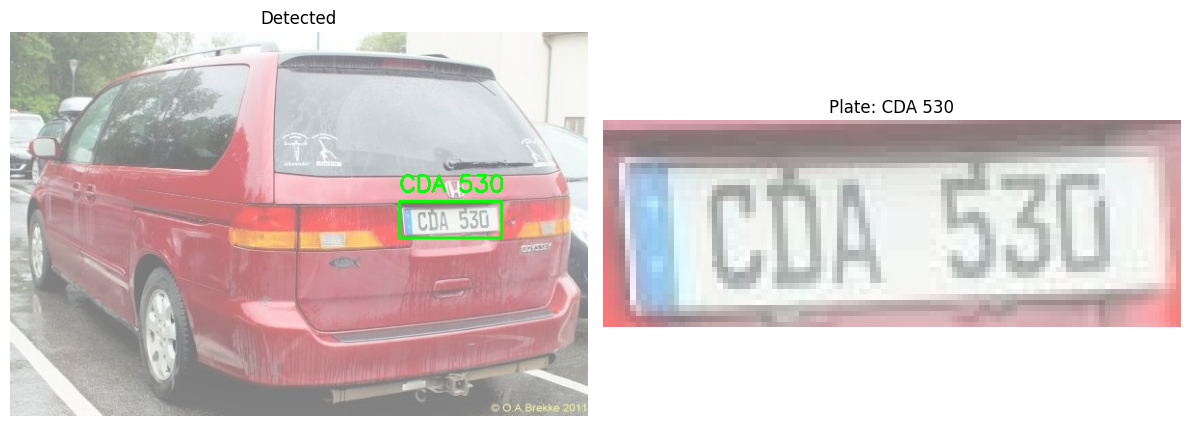

Plate 1: CDA 530


In [29]:

IMAGE_PATH = './data/foggy-license-plate-dataset/test/images/pic_030_jpg.rf.00b19db8e9be00184b8a01f0b6bb6fe4.jpg'  

# Usage
detect(IMAGE_PATH)


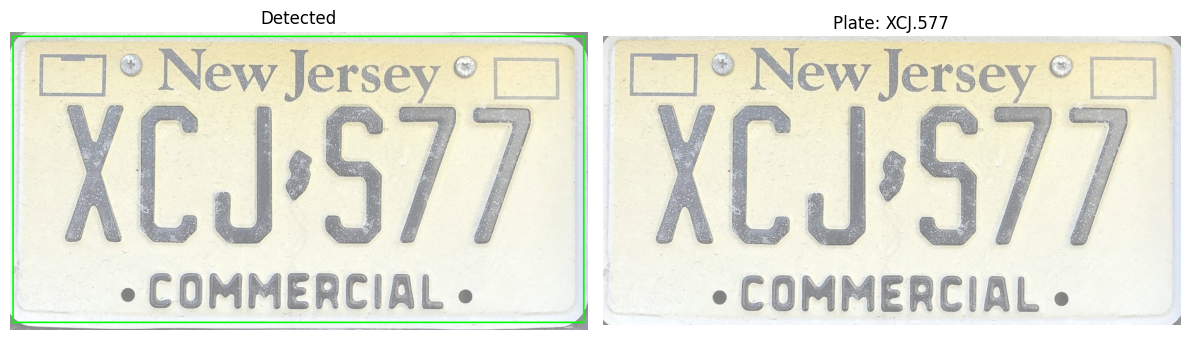

Plate 1: XCJ.577


In [26]:
name='52-1024px-NJ_commercial_license_plate_XCJ-S77_jpg.rf.a2d995413cd540ffeba6e0b01b3e8108'
IMAGE_PATH = f'./data/foggy-license-plate-dataset/test/images/{name}.jpg'  

# Usage
detect(IMAGE_PATH)

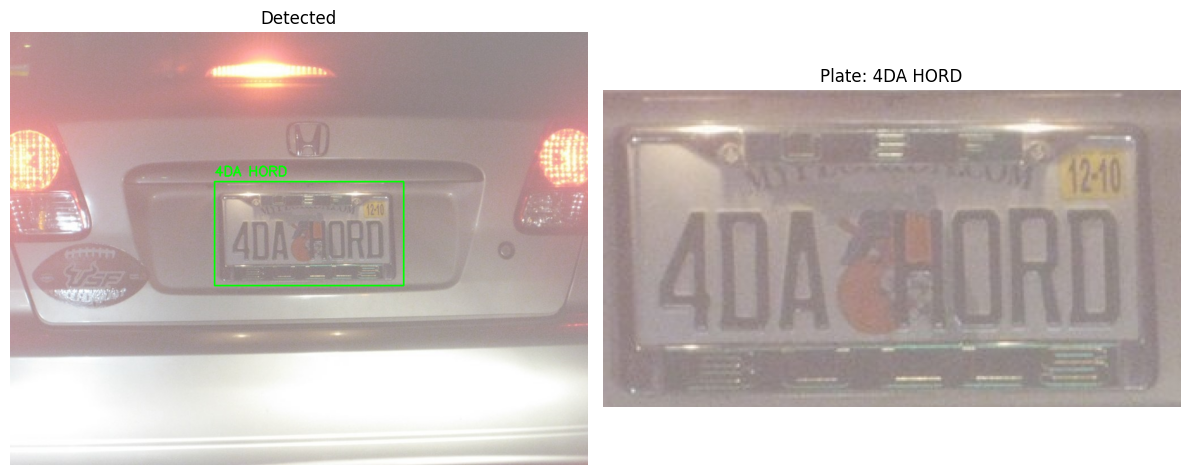

Plate 1: 4DA HORD


In [28]:
name='02a3ba4c3886fe9a_jpg.rf.3e8359561ec92f1bbbe9f7ca5454eb44'
IMAGE_PATH = f'./data/foggy-license-plate-dataset/test/images/{name}.jpg'  

# Usage
detect(IMAGE_PATH)


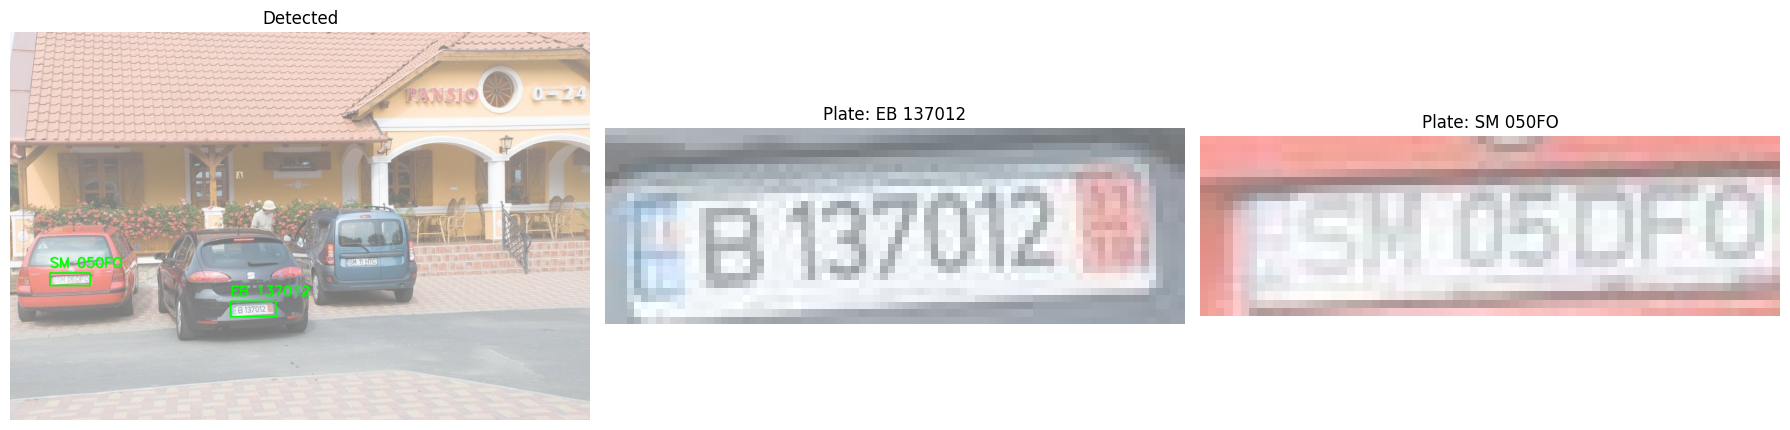

Plate 1: EB 137012
Plate 2: SM 050FO


In [29]:
name='0026c246d5c33bea_jpg.rf.e9b4d443d16831c5edd576804bb54beb'
IMAGE_PATH = f'./data/foggy-license-plate-dataset/test/images/{name}.jpg'  

# Usage
detect(IMAGE_PATH)

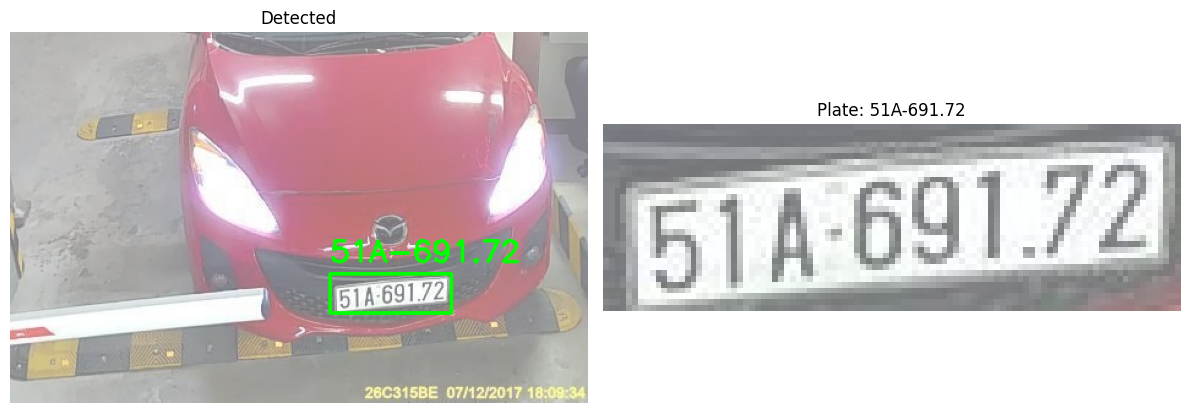

Plate 1: 51A-691.72


In [30]:
name='CarLongPlate685_jpg.rf.18897b02400b6ecc6181302082b2bc2a'
IMAGE_PATH = f'./data/foggy-license-plate-dataset/test/images/{name}.jpg'  

# Usage
detect(IMAGE_PATH)

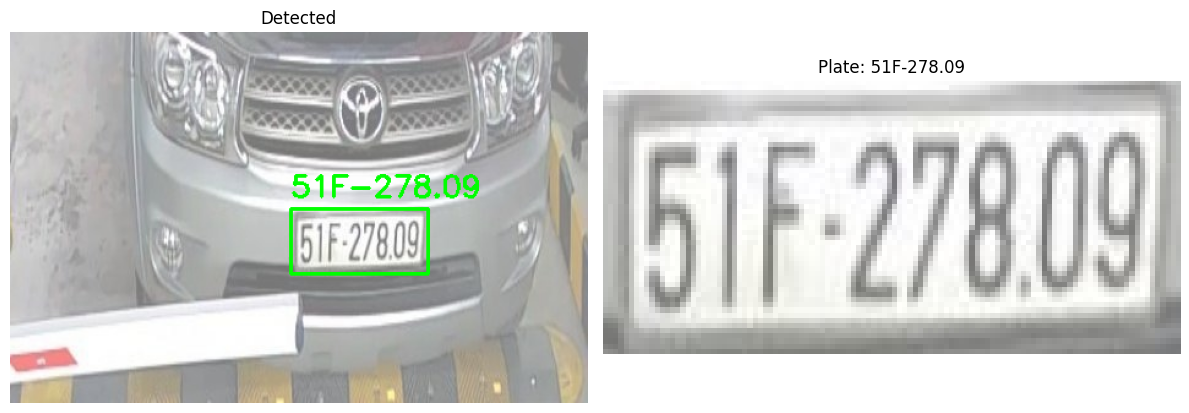

Plate 1: 51F-278.09


In [19]:
name='CarLongPlateGen2903_jpg.rf.228195bbfa7e7b937b47e57dbc9d3e94'
IMAGE_PATH = f'./data/foggy-license-plate-dataset/test/images/{name}.jpg'  

# Usage
detect(IMAGE_PATH)